C:\Users\User\AppData\Local\Temp\ipykernel_8480\1194165618.py:16: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['work_interfere'] = pd.Categorical(df['work_interfere'], categories=work_order, ordered=True)


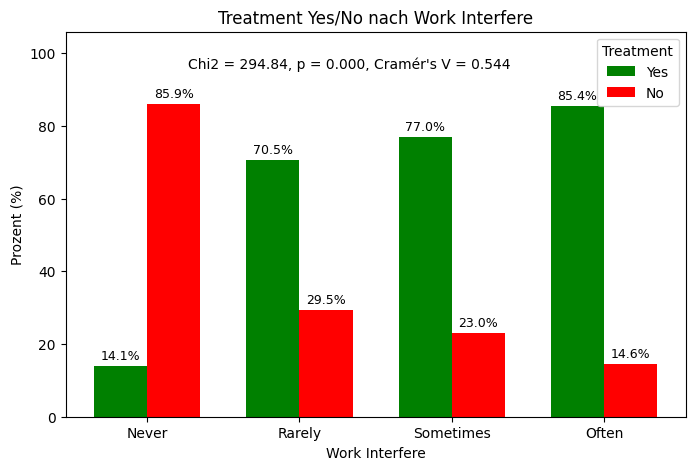

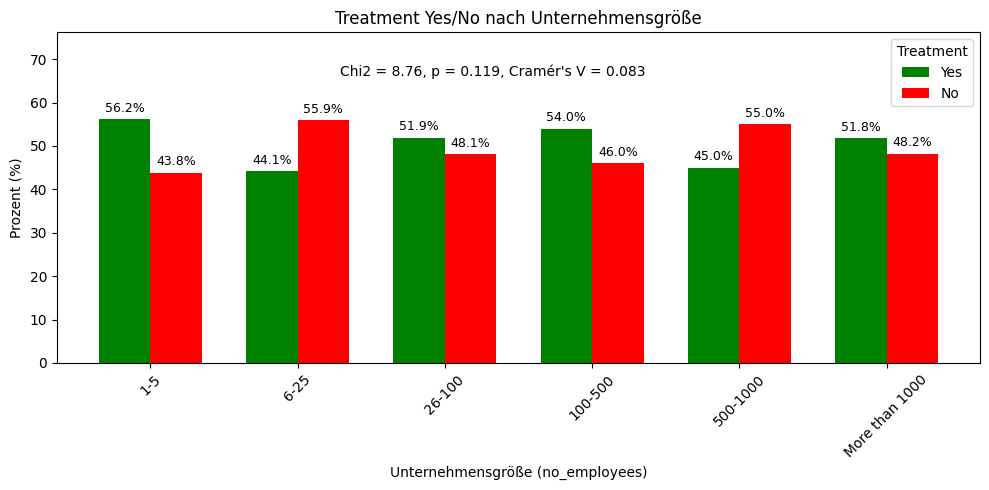

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# --- Daten einlesen ---
df = pd.read_csv("survey.csv")

# --- Treatment standardisieren ---
df['treatment'] = df['treatment'].str.strip().str.capitalize()  # Yes/No

# --- Work Interfere standardisieren ---
df['work_interfere'] = df['work_interfere'].fillna('NA').str.strip().str.capitalize()
# Reihenfolge festlegen
work_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'NA']
df['work_interfere'] = pd.Categorical(df['work_interfere'], categories=work_order, ordered=True)

# --- Kreuztabelle Work_interfere vs Treatment ---
ct_work = pd.crosstab(df['work_interfere'], df['treatment'])
ct_work_percent = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100

# --- Chi-Quadrat-Test ---
chi2_work, p_work, dof_work, expected_work = chi2_contingency(ct_work)
n_work = ct_work.to_numpy().sum()
cramers_v_work = np.sqrt(chi2_work / (n_work * (min(ct_work.shape)-1)))

# --- Balkendiagramm Work_interfere ---
fig, ax = plt.subplots(figsize=(8,5))
width = 0.35
categories = ct_work_percent.index.tolist()
treatments = ['Yes', 'No']
x = range(len(categories))
colors = {"Yes": "green", "No": "red"}

for i, treatment in enumerate(treatments):
    heights = ct_work_percent[treatment].values
    ax.bar([p + i*width for p in x], heights, width=width, label=treatment, color=colors[treatment])
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# Signifikanzannotation
x_mitte = (0 + len(categories) - 1) / 2
y_hoch = ct_work_percent.values.max() + 10
ax.text(x_mitte, y_hoch, 
        f"Chi2 = {chi2_work:.2f}, p = {p_work:.3f}, Cramér's V = {cramers_v_work:.3f}", 
        fontsize=10, ha='center')

ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Work Interfere")
ax.set_title("Treatment Yes/No nach Work Interfere")
ax.set_ylim(0, ct_work_percent.values.max() + 20)
ax.legend(title="Treatment")
plt.show()


# --- no_employees standardisieren ---
df['no_employees'] = df['no_employees'].str.strip()
# Reihenfolge von klein nach groß
emp_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df['no_employees'] = pd.Categorical(df['no_employees'], categories=emp_order, ordered=True)

# --- Kreuztabelle no_employees vs Treatment ---
ct_emp = pd.crosstab(df['no_employees'], df['treatment'])
ct_emp_percent = pd.crosstab(df['no_employees'], df['treatment'], normalize='index') * 100

# --- Chi-Quadrat-Test ---
chi2_emp, p_emp, dof_emp, expected_emp = chi2_contingency(ct_emp)
n_emp = ct_emp.to_numpy().sum()
cramers_v_emp = np.sqrt(chi2_emp / (n_emp * (min(ct_emp.shape)-1)))

# --- Balkendiagramm no_employees ---
fig, ax = plt.subplots(figsize=(10,5))
categories_emp = ct_emp_percent.index.tolist()
x_emp = range(len(categories_emp))

for i, treatment in enumerate(treatments):
    heights = ct_emp_percent[treatment].values
    ax.bar([p + i*width for p in x_emp], heights, width=width, label=treatment, color=colors[treatment])
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# Signifikanzannotation
x_mitte_emp = (0 + len(categories_emp) - 1) / 2
y_hoch_emp = ct_emp_percent.values.max() + 10
ax.text(x_mitte_emp, y_hoch_emp, 
        f"Chi2 = {chi2_emp:.2f}, p = {p_emp:.3f}, Cramér's V = {cramers_v_emp:.3f}", 
        fontsize=10, ha='center')

ax.set_xticks([p + width/2 for p in x_emp])
ax.set_xticklabels(categories_emp, rotation=45)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Unternehmensgröße (no_employees)")
ax.set_title("Treatment Yes/No nach Unternehmensgröße")
ax.set_ylim(0, ct_emp_percent.values.max() + 20)
ax.legend(title="Treatment")
plt.tight_layout()
plt.show()